In [2]:
from AgentBasedModel import *
from AgentBasedModel.params_calibration.utils_calibration import *
from AgentBasedModel.params_calibration.calibrationv3.utils_calibration_v2 import *
import random
import numpy as np
import optuna

In [3]:
# всякие константы для обучения
N_RUNS = 4
N_TICKS = 1000
EXCHANGE_VOLUME = 1000

target_params = pd.read_csv('mean_std_ethusdt_validation_data2.csv')
NORM_COEF_LR = 1 / target_params.loc[target_params["param"] == 'mean_on_ret2', "mean"].iloc[0]
W = pd.read_csv('weights(inv_covariance_matrix_from_real_data).csv').to_numpy()

In [4]:
# метрика лосса: матрица ковариаций
# + байесовское обучение оптуной, все диапазоны были выбраны обще (далее будут сужаться)
def loss_msm(t_params, m_params):
    num = ['mean_on_ret2', "std_on_ret2", "q1_on_ret2", "q5_on_ret2", "q95_on_ret2", "q99_on_ret2", "kurtosis_on_ret2", "skewness_on_ret", "autocorr_on_ret_1", "autocorr_on_ret_5", "autocorr_on_ret_10", "autocorr_on_abs_1", "autocorr_on_abs_5", "autocorr_on_abs_10"]
    errors = np.zeros((len(num), 1))
    id = -1
    for i in num:
        id += 1
        errors[id] = t_params.loc[t_params["param"] == i, "mean"].iloc[0] - m_params[i]
    ans = errors.T @ W @ errors
    # print(ans.shape)
    return float(ans[0][0])

def objective(trial):
    params = {
        'Random': trial.suggest_int('Random', 5, 100),
        'Fundamentalist': trial.suggest_int('Fundamentalist', 5, 100),
        'Chartist': trial.suggest_int('Chartist', 5, 100),
        'Universalist': trial.suggest_int('Universalist', 5, 100),
        'MarketMaker': trial.suggest_int('MarketMaker', 0, 1),
        'Transaction_cost': trial.suggest_float("Transaction_cost", 1e-4, 1e-1, log=True),
        'Std':  trial.suggest_float("Std", 1e-1, 1e2, log=True),
        'Std_Random':  trial.suggest_float("Std_Random", 1e-2, 1e1, log=True),
        'Avg_Traders': trial.suggest_float("Avg_Traders", -5, 0),
        'Last_Step': trial.suggest_float("Last_Step", 0, 1),
        'Last_Ret': trial.suggest_float("Last_Ret", 1e-3, 50, log=True),
        'Noisy_Level': trial.suggest_float("Noisy_Level", 1e-3, 5, log=True)
    }
    errors = []

    for run_idx in range(N_RUNS):
        random.seed(42 + run_idx)
        np.random.seed(42 + run_idx)

        try:
            exchange = ExchangeAgent(std=params['Std'], transaction_cost=params['Transaction_cost'], std_random=params['Std_Random'], divs_drifted=True)
            simulator2 = Simulator(**{
                'exchange': exchange,
                'traders': [
                    *[Random(exchange, EXCHANGE_VOLUME) for _ in range(params['Random'])],
                    *[Fundamentalist(exchange, EXCHANGE_VOLUME) for _ in range(params['Fundamentalist'])],
                    *[Chartist(exchange, EXCHANGE_VOLUME) for _ in range(params['Chartist'])],
                    *[Universalist(exchange, EXCHANGE_VOLUME) for _ in range(params['Universalist'])],
                    *[MarketMaker(exchange, EXCHANGE_VOLUME) for _ in range(params['MarketMaker'])],
                ],
            }, avg_traders=params['Avg_Traders'], last_step=params['Last_Step'], last_ret=params['Last_Ret'], noisy_level=params['Noisy_Level'], norm_coef_lr=NORM_COEF_LR)

            simulator2.simulate(N_TICKS, silent=True)
            prices = np.array(simulator2.info.prices)
            model_params = pipeline(prices, is_print=0)
            errors.append(loss_msm(target_params, model_params))
        except Exception as e:
            print("Run failed:", run_idx, e)
            continue

    if len(errors) != N_RUNS:
        return 100000
    return float(np.mean(errors))

In [5]:
# само обучение
study_msm = optuna.create_study(study_name="calibration_msm(exchange_volume=1000)", direction="minimize", storage="sqlite:///calibration_msm(exchange_volume=1000).db",  load_if_exists=True)
study_msm.optimize(objective, show_progress_bar=True, n_trials=500)

best_params = study_msm.best_params
best_score = study_msm.best_value
print('Best params:', best_params)
print('Best Score:', best_score)

[I 2026-04-25 20:42:10,909] A new study created in RDB with name: calibration_msm(exchange_volume=1000)
Best trial: 0. Best value: 1612.63:   0%|          | 1/500 [00:10<1:27:47, 10.56s/it]

[I 2026-04-25 20:42:21,462] Trial 0 finished with value: 1612.629945470782 and parameters: {'Random': 58, 'Fundamentalist': 9, 'Chartist': 8, 'Universalist': 29, 'MarketMaker': 1, 'Transaction_cost': 0.04372244660749451, 'Std': 0.6867075242190364, 'Std_Random': 7.866404010174966, 'Avg_Traders': -3.8298798319955205, 'Last_Step': 0.19212949599449547, 'Last_Ret': 6.247960325458863, 'Noisy_Level': 0.1798715465672767}. Best is trial 0 with value: 1612.629945470782.


Best trial: 0. Best value: 1612.63:   0%|          | 2/500 [00:16<1:06:53,  8.06s/it]

[I 2026-04-25 20:42:27,777] Trial 1 finished with value: 1981.5592690343462 and parameters: {'Random': 22, 'Fundamentalist': 20, 'Chartist': 15, 'Universalist': 60, 'MarketMaker': 0, 'Transaction_cost': 0.0005795391152644822, 'Std': 1.4318313349819205, 'Std_Random': 0.5803188174715775, 'Avg_Traders': -4.844835322011317, 'Last_Step': 0.12368669145121358, 'Last_Ret': 15.223821493595763, 'Noisy_Level': 0.0023731415455814993}. Best is trial 0 with value: 1612.629945470782.


Best trial: 0. Best value: 1612.63:   1%|          | 3/500 [00:42<2:11:27, 15.87s/it]

...

[I 2026-04-25 21:56:43,444] Trial 497 finished with value: 26.30734409166483 and parameters: {'Random': 72, 'Fundamentalist': 11, 'Chartist': 74, 'Universalist': 7, 'MarketMaker': 1, 'Transaction_cost': 0.0003809563008097481, 'Std': 4.3535891437131715, 'Std_Random': 0.06885817139966915, 'Avg_Traders': -3.2627382546841597, 'Last_Step': 0.3680251111131881, 'Last_Ret': 0.020596826904507093, 'Noisy_Level': 0.0024432391051469058}. Best is trial 461 with value: 11.310939531853737.


Best trial: 461. Best value: 11.3109: 100%|█████████▉| 499/500 [1:14:38<00:06,  6.31s/it]

[I 2026-04-25 21:56:49,245] Trial 498 finished with value: 14.273166034930773 and parameters: {'Random': 69, 'Fundamentalist': 7, 'Chartist': 77, 'Universalist': 6, 'MarketMaker': 1, 'Transaction_cost': 0.00033684344441799907, 'Std': 3.4859114675042564, 'Std_Random': 0.29227735487612067, 'Avg_Traders': -3.158086126302032, 'Last_Step': 0.34407431208116784, 'Last_Ret': 0.017575937806829527, 'Noisy_Level': 0.0022709534684994775}. Best is trial 461 with value: 11.310939531853737.


Best trial: 461. Best value: 11.3109: 100%|██████████| 500/500 [1:14:42<00:00,  8.96s/it]

[I 2026-04-25 21:56:53,208] Trial 499 finished with value: 24.302025182072363 and parameters: {'Random': 69, 'Fundamentalist': 5, 'Chartist': 52, 'Universalist': 5, 'MarketMaker': 1, 'Transaction_cost': 0.00043028038658040723, 'Std': 4.06352673604253, 'Std_Random': 0.07961300304686955, 'Avg_Traders': -3.205488606431517, 'Last_Step': 0.3525164206574425, 'Last_Ret': 0.015980946898036905, 'Noisy_Level': 0.002288632731109858}. Best is trial 461 with value: 11.310939531853737.
Best params: {'Random': 79, 'Fundamentalist': 7, 'Chartist': 88, 'Universalist': 5, 'MarketMaker': 1, 'Transaction_cost': 0.00012666834758034688, 'Std': 2.3225204684443703, 'Std_Random': 0.0506768950167496, 'Avg_Traders': -2.926226659492769, 'Last_Step': 0.4210116107139582, 'Last_Ret': 0.015213000762259373, 'Noisy_Level': 0.002244672582276818}
Best Score: 11.310939531853737


[I 2026-04-27 01:59:55,117] Using an existing study with name 'calibration_msm(exchange_volume=1000)' instead of creating a new one.
C:\Users\rodion\AppData\Local\Temp\ipykernel_26764\1849925540.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_msm)


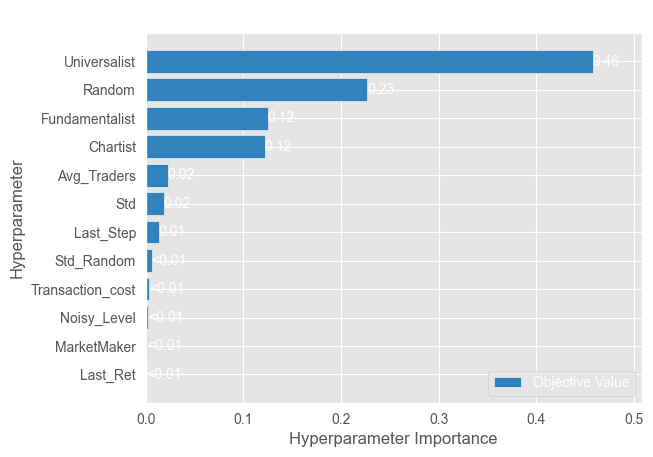

In [8]:
from optuna.visualization.matplotlib import plot_param_importances
import sklearn

study_msm = optuna.create_study(study_name="calibration_msm(exchange_volume=1000)", direction="minimize", storage="sqlite:///calibration_msm(exchange_volume=1000).db",  load_if_exists=True)
plot_param_importances(study_msm)
plt.show()

In [7]:
best_params = study_msm.best_params
best_score = study_msm.best_value
print('Best params:', best_params)
print('Best Score:', best_score)

Best params: {'Random': 79, 'Fundamentalist': 7, 'Chartist': 88, 'Universalist': 5, 'MarketMaker': 1, 'Transaction_cost': 0.00012666834758034688, 'Std': 2.3225204684443703, 'Std_Random': 0.0506768950167496, 'Avg_Traders': -2.926226659492769, 'Last_Step': 0.4210116107139582, 'Last_Ret': 0.015213000762259373, 'Noisy_Level': 0.002244672582276818}
Best Score: 11.310939531853737


C:\Users\rodion\AppData\Local\Temp\ipykernel_26764\1604666724.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_param_importances(study_msm)


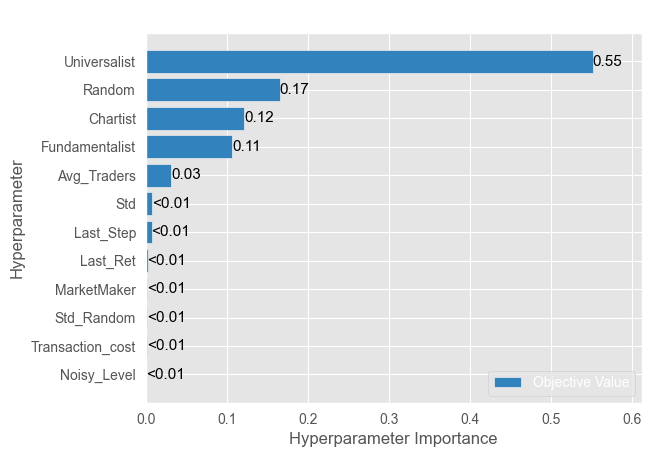

In [9]:
ax = plot_param_importances(study_msm)
for txt in ax.texts:
    txt.set_color("black")   # можно "yellow", "red", "#ffffff" и т.д.
    txt.set_fontsize(11)

plt.show()